In [1]:
from google.colab import drive
drive.mount('/content/drive')




Mounted at /content/drive


In [2]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Step 2: Load Dataset
data = pd.read_csv("/content/drive/MyDrive/Healthcare/Dataset/heart_disease_uci.csv")  # Change path if needed
print("First 5 rows:\n", data.head())

First 5 rows:
    id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal 

In [6]:

print("\nDataset Info:\n", data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Dataset Info:
 None


In [8]:
print("\nTarget distribution:\n", data['num'].value_counts())


Target distribution:
 num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [9]:
data = data.drop(columns=['id', 'dataset'])

In [10]:
# Step 4: Binarize target
data['target'] = data['num'].apply(lambda x: 1 if x > 0 else 0)
data = data.drop(columns=['num'])


In [11]:
# Step 5: Handle missing values
# Numeric columns → fill median
numeric_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

# Categorical / boolean columns → fill mode
categorical_cols = ['fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'sex', 'cp']
for col in categorical_cols:
    if col in data.columns:
        data[col] = data[col].fillna(data[col].mode()[0])

/tmp/ipython-input-1536498957.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].fillna(data[col].mode()[0])


In [12]:
# Step 6: Encode boolean columns
data['fbs'] = data['fbs'].replace({'True':1,'False':0})
data['exang'] = data['exang'].replace({'True':1,'False':0})

In [13]:
# Step 7: Encode categorical columns
categorical_cols = ['sex', 'cp', 'restecg', 'slope', 'ca', 'thal']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [14]:
# Step 8: Separate features and target
X = data.drop('target', axis=1)
y = data['target']

In [15]:
# Step 9: Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [16]:
# Step 10: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [17]:
# Step 11: Train Models
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:00:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [18]:
# Step 12: Evaluate Models
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, "XGBoost")



--- Logistic Regression ---
Accuracy: 0.7880434782608695
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.80      0.75        75
           1       0.85      0.78      0.81       109

    accuracy                           0.79       184
   macro avg       0.78      0.79      0.78       184
weighted avg       0.79      0.79      0.79       184

Confusion Matrix:
 [[60 15]
 [24 85]]

--- Random Forest ---
Accuracy: 0.8532608695652174
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.82        75
           1       0.89      0.86      0.87       109

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

Confusion Matrix:
 [[63 12]
 [15 94]]

--- XGBoost ---
Accuracy: 0.8478260869565217
Classification Report:
               precision    recall  f1-scor

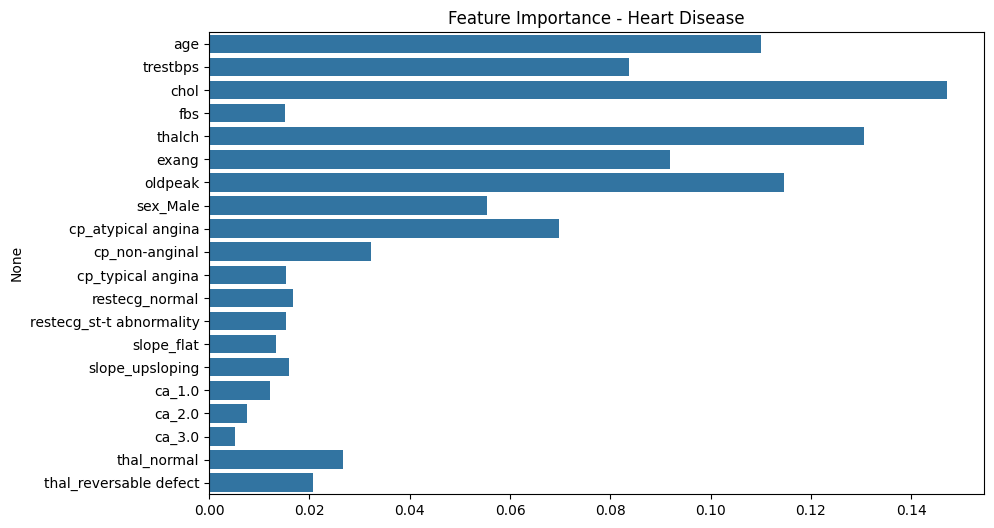

In [19]:
# Step 13: Feature Importance (Random Forest)
feature_importance = rf.feature_importances_
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance, y=X.columns)
plt.title("Feature Importance - Heart Disease")
plt.show()

In [20]:
# Step 7: Save Best Model and Scaler
joblib.dump(rf, "/content/drive/MyDrive/Healthcare/models/heart_model.pkl")   # Replace 'rf' with best model if needed
joblib.dump(scaler, "/content/drive/MyDrive/Healthcare/models/heart_scaler.pkl")

print("\nHeart Disease model and scaler saved successfully!")


Heart Disease model and scaler saved successfully!
